<a href="https://colab.research.google.com/github/Amarnath2908/DEEP-LEARNING/blob/main/DL1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CarPrice_dataset.csv to CarPrice_dataset.csv


In [ ]:
df = pd.read_csv("CarPrice_dataset.csv")

In [ ]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
200,False
201,False
202,False
203,False


In [ ]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
x = df.drop('price', axis=1)
y = df['price']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import argmax

In [ ]:
# Define the model
model = Sequential()

# Input layer + Hidden Layer 1
model.add(Dense(512, activation='relu', input_shape=(x_train.shape[1],)))
# Hidden Layer 2
model.add(Dense(256, activation='relu'))
# Output Layer
model.add(Dense(1))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │        97,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,377 (896.00 KB)

 Trainable params: 229,377 (896.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [ ]:
history = model.fit(x_train,y_train,epochs=70,batch_size = 32)

Epoch 1/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 247300368.0000
Epoch 2/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 236689680.0000
Epoch 3/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 246034912.0000
Epoch 4/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 218503712.0000
Epoch 5/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 222628064.0000
Epoch 6/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 208701008.0000
Epoch 7/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 234684400.0000
Epoch 8/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 209750608.0000
Epoch 9/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 235708560.0000
Epoch 10/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 228158736.0000
Epoch 11/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 232140320.0000
Epoch 12/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 208164960.0000
Epoch 13/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 219148960.0000
Epoch 14/70
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 20

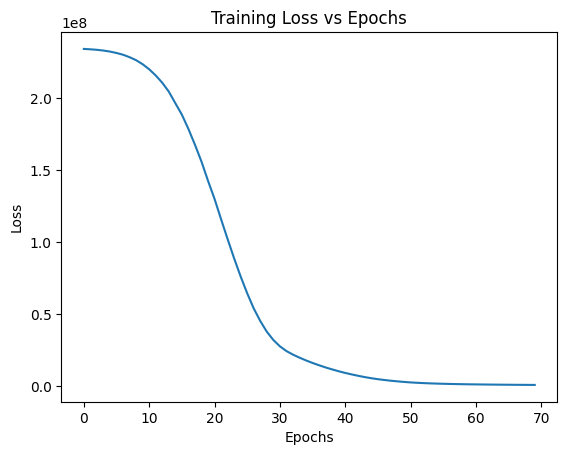

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title('Training Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(x_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print("Model Evaluation Metrics:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Model Evaluation Metrics:
Mean Absolute Error (MAE): 2542.0900460175303
Mean Squared Error (MSE): 12218668.072810225
Root Mean Squared Error (RMSE): 3495.5211446664466
R2 Score: 0.8452236415543569


In [ ]:
df.head()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
1,2,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
2,3,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,False,False,False,False,False,False,False,True,False,False
3,4,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False
4,5,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False


,price
0,13495.0
1,16500.0
2,16500.0
3,13950.0
4,17450.0
...,...
200,16845.0
201,19045.0
202,21485.0
203,22470.0


In [ ]:
new_data = x.iloc[[0]]
new_data_processed = sc.transform(new_data)

predicted_price = model.predict(new_data_processed)
print("Predicted Price:", predicted_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted Price: 13775.512
